In [25]:
import numpy as np
import pandas as pd
import os

## Funções e Configurações

In [26]:
# this dictionary contains the configuration necessary to divide each dataset used in the work, the script is made
# for the conll type of datasets, so if you want to add datasets to divide, make sure to add it here
gen_config = {
    'leNER':{
        'base_dir': "../Base de Dados/leNER/",
        'load_dir': "documents/allDoc/",
        'save_dir': "divisions/iterative/",
        'col_sep' : ' ',
        'file_type': '.conll',
    },
    'UlyssesNER-BR':{
        'base_dir': "../Base de Dados/UlyssesNER-BR/",
        'load_dir': "PL_Corpus_byTypes_conll/",
        'save_dir': "divisions/iterative/",
        'col_sep' : ' ',
        'file_type': '.conll',
    },
    'Harem-second':{
        'base_dir': "../Base de Dados/HAREM/",
        'load_dir': "SecondHarem/documents",
        'save_dir': "divisions/second/iterative/",
        'col_sep' : '\t',
        'file_type': '.conll',
    },
    'Harem-first':{
        'base_dir': "../Base de Dados/HAREM/",
        'load_dir': "fistHarem/documents",
        'save_dir': "divisions/first/iterative/",
        'col_sep' : '\t',
        'file_type': '.conll',
    },
    'Harem-mini':{
        'base_dir': "../Base de Dados/HAREM/",
        'load_dir': "miniHarem/documents",
        'save_dir': "divisions/mini/iterative/",
        'col_sep' : '\t',
        'file_type': '.conll',
    }
}

In [27]:
def get_sentencas(corpus, coll_sep):
        sentenca = []
        for line in corpus:
            if line == '\n':
                if sentenca:
                    yield sentenca
                    sentenca = []
            else:
                
                sentenca.append(line.strip('\n').split(coll_sep))
        if sentenca:
            yield sentenca

In [32]:
def read_dataset(filepath, coll_sep):
    data_por_sentenca = []
    
    with open(filepath, "r", encoding="utf-8") as corpus:
        data_por_sentenca += list(get_sentencas(corpus, coll_sep))
    
    return data_por_sentenca

In [33]:
def get_data(config, selective = False, fileName = ""):
    load_dir = config['base_dir'] + config['load_dir']
    sep = config['col_sep']
    if selective:
        fp = load_dir + fileName
        return read_dataset(filepath=fp, coll_sep=sep)
    else:
        filepaths = []
        for file in os.listdir(load_dir):
            if file.endswith(config['file_type']):
                filepaths.append(load_dir + file)
        
        data_por_sentenca = []
        for filepath in filepaths:
            print(filepath+"\n")
            data_por_sentenca += read_dataset(filepath=filepath, coll_sep=sep)
        
        return data_por_sentenca

In [34]:
def split_token_label(data):
    return list(map(list,zip(*data)))

## Carregando DataSet e preparando dados

In [35]:
# dataset = 'leNER'
# dataset = 'Paramopama'
# dataset = 'Harem-mini'
dataset = 'Harem-mini'
# dataset = 'UlyssesNER-BR'

config = gen_config[dataset]

filepaths = []

try:
    # Listar arquivos na pasta especificada no config
    full_path = config['base_dir'] + config['load_dir']
    files = os.listdir(full_path)
    print(f"Arquivos encontrados em {full_path}: {files}")
    for file in files:
        # Adicionar o caminho completo de cada arquivo à lista
        filepaths.append(full_path + file)
except FileNotFoundError:
    print(f"Erro: O diretório {full_path} não foi encontrado. Verifique o caminho no 'config'.")

# Caminho específico para o diretório de documentos do HAREM
folder_path = '../Base de Dados/HAREM/miniHarem/documents'
data_por_sentenca_por_doc = {}

# Verificar se o diretório existe antes de tentar acessá-lo
if os.path.exists(folder_path):
    for file in os.listdir(folder_path):
        filepath = os.path.join(folder_path, file)
        
        # Verificar se o item listado é um arquivo
        if os.path.isfile(filepath):
            try:
                # Ler o dataset e armazenar no dicionário
                data_por_sentenca_por_doc[file] = read_dataset(filepath, coll_sep=config['col_sep'])
                print(f"Documento carregado: {file}")  # Exibir o nome do documento carregado
            except Exception as e:
                print(f"Erro ao processar o arquivo {file}: {e}")
else:
    print(f"O diretório {folder_path} não existe. Verifique o caminho e tente novamente.")

# Exibir o total de documentos carregados e seus nomes
total_documentos = len(data_por_sentenca_por_doc)
print(f"Total de documentos carregados: {total_documentos}")

if total_documentos > 0:
    print("Nomes dos documentos carregados:")
    for doc in data_por_sentenca_por_doc.keys():
        print(doc)
else:
    print("Nenhum documento foi carregado.")


Arquivos encontrados em ../Base de Dados/HAREM/miniHarem/documents: ['HAREM-002-09992', 'HAREM-00B-05108', 'HAREM-00J-04761', 'HAREM-00J-08768', 'HAREM-016-08478', 'HAREM-01B-03438', 'HAREM-01J-09708', 'HAREM-021-07181', 'HAREM-021-08749', 'HAREM-02B-04508', 'HAREM-047-08709', 'HAREM-04C-06438', 'HAREM-112-00694', 'HAREM-117-06259', 'HAREM-118-02739', 'HAREM-11K-09659', 'HAREM-125-00429', 'HAREM-12B-03899', 'HAREM-132-02310', 'HAREM-132-06332', 'HAREM-141-03120', 'HAREM-145-01159', 'HAREM-146-06959', 'HAREM-147-02919', 'HAREM-14J-01729', 'HAREM-201-05802', 'HAREM-20J-06060', 'HAREM-20J-06850', 'HAREM-21B-02110', 'HAREM-222-02106', 'HAREM-227-09906', 'HAREM-22J-04380', 'HAREM-22J-07508', 'HAREM-232-00969', 'HAREM-232-07191', 'HAREM-241-08522', 'HAREM-24J-08440', 'HAREM-301-04429', 'HAREM-308-07171', 'HAREM-312-00687', 'HAREM-328-05696', 'HAREM-32J-00801', 'HAREM-339-04891', 'HAREM-339-08891', 'HAREM-33J-02267', 'HAREM-33J-08671', 'HAREM-33K-02481', 'HAREM-40J-06242', 'HAREM-411-03995', 

In [36]:
# data_por_sentenca_por_doc['HAREMdoc_aa64686'][0]
# len(data_por_sentenca_por_doc['HAREMdoc_aa64686'])
# data_por_sentenca_por_doc[list(data_por_sentenca_por_doc.keys())[0]]
# d = list(data_por_sentenca_por_doc.values())[0][10][-1]
# list(map(list,zip(d)))
# # d

In [37]:
import re
from collections import Counter

# Definir abreviações comuns
abreviacoes = ['Dr.', 'Sra.', 'Sr.', 'Jr.', 'U.S.', 'etc.', 'i.e.', 'e.g.']

# Função para contar as frases corretamente
def contar_frases(sentenca):
    # Substituir as abreviações por marcadores temporários
    for abreviacao in abreviacoes:
        sentenca = sentenca.replace(abreviacao, f"__{abreviacao}__")
    
    # Dividir a sentença por ponto final seguido de espaço
    frases = re.split(r'(?<=\.)\s+', sentenca)
    
    # Restaurar as abreviações
    for abreviacao in abreviacoes:
        sentenca = sentenca.replace(f"__{abreviacao}__", abreviacao)
    
    return len(frases)

# Dicionário para armazenar as contagens de frases e entidades por documento
sentencas_por_doc = {}
total_frases = 0
labels_por_doc = {}

# Iterar sobre os documentos
for docName, docData in data_por_sentenca_por_doc.items():
    allDocData = []
    doc_labels = []

    for sentence in docData:
        allDocData += [i for i in sentence]
        
        # Extrair tokens e labels de cada sentença
        docTokens, docLabels = split_token_label(allDocData)  # Supondo que você já tenha essa função

        # Armazenar as labels no dicionário de contagem de rótulos
        labels_por_doc[docName] = dict(Counter(docLabels))
        
        # Contar as frases no documento atual
        for sentenca in docData:
            total_frases += contar_frases(' '.join([palavra for palavra, _ in sentenca]))  # Contar frases de uma sentença

    # Exibir as sentenças por documento
    sentencas_por_doc[docName] = docData

# Exibir as contagens de rótulos por documento
for doc, labels_count in labels_por_doc.items():
    print(f"Documento: {doc}")
    print("Contagem de rótulos:", labels_count)
    print()

# Exibir as sentenças por documento
for doc, sentencas in sentencas_por_doc.items():
    print(f"Documento: {doc}")
    print("Sentenças:")
    for sentenca in sentencas:
        print(" ", ' '.join([palavra for palavra, _ in sentenca]))  # Exibir as palavras (sem tags)
    print()

# Exibir o total de frases de todos os documentos
print("Total de frases em todos os documentos:", total_frases)



Documento: HAREM-002-09992
Contagem de rótulos: {'B-ORGANIZACAO': 14, 'I-ORGANIZACAO': 11, 'O': 295, 'B-LOCAL': 14, 'I-LOCAL': 14, 'B-ABSTRACCAO': 2, 'B-PESSOA': 9, 'I-PESSOA': 8, 'B-VALOR': 7, 'I-VALOR': 7, 'B-TEMPO': 5, 'B-OBRA': 1, 'I-OBRA': 5, 'I-TEMPO': 1}

Documento: HAREM-00B-05108
Contagem de rótulos: {'O': 130, 'B-LOCAL': 22, 'I-LOCAL': 5}

Documento: HAREM-00J-04761
Contagem de rótulos: {'B-ORGANIZACAO': 5, 'O': 228, 'I-ORGANIZACAO': 2, 'B-TEMPO': 1, 'I-TEMPO': 2, 'B-LOCAL': 1, 'B-PESSOA': 4, 'B-OUTRO': 2, 'I-PESSOA': 1, 'B-OBRA': 1, 'B-COISA': 2}

Documento: HAREM-00J-08768
Contagem de rótulos: {'O': 170, 'B-ABSTRACCAO': 1, 'I-ABSTRACCAO': 2, 'B-PESSOA': 2, 'I-PESSOA': 2, 'B-ORGANIZACAO': 2, 'B-OBRA': 4, 'B-LOCAL': 4, 'B-TEMPO': 2, 'I-OBRA': 5}

Documento: HAREM-016-08478
Contagem de rótulos: {'O': 678, 'B-TEMPO': 4, 'B-PESSOA': 8, 'B-COISA': 6, 'I-COISA': 5, 'B-VALOR': 1, 'I-PESSOA': 1}

Documento: HAREM-01B-03438
Contagem de rótulos: {'O': 1078, 'B-PESSOA': 27, 'I-PESSOA':

In [38]:


from collections import Counter
labels_por_doc = {}

for docName, docData in data_por_sentenca_por_doc.items():
    allDocData = []
    
    for sentence in docData:
        allDocData += [i for i in sentence]
    
    docTokens, docLabels = split_token_label(allDocData)
    
    
    labels_por_doc[docName] = docLabels

    labels_count = Counter(docLabels)
    
    # Armazenar a contagem de rótulos para o documento atual
    labels_por_doc[docName] = dict(labels_count)

# Exibir as contagens de rótulos por documento
for doc, labels_count in labels_por_doc.items():
    print(f"Documento: {doc}")
    print("Contagem de rótulos:", labels_count)
    print()

Documento: HAREM-002-09992
Contagem de rótulos: {'B-ORGANIZACAO': 14, 'I-ORGANIZACAO': 11, 'O': 295, 'B-LOCAL': 14, 'I-LOCAL': 14, 'B-ABSTRACCAO': 2, 'B-PESSOA': 9, 'I-PESSOA': 8, 'B-VALOR': 7, 'I-VALOR': 7, 'B-TEMPO': 5, 'B-OBRA': 1, 'I-OBRA': 5, 'I-TEMPO': 1}

Documento: HAREM-00B-05108
Contagem de rótulos: {'O': 130, 'B-LOCAL': 22, 'I-LOCAL': 5}

Documento: HAREM-00J-04761
Contagem de rótulos: {'B-ORGANIZACAO': 5, 'O': 228, 'I-ORGANIZACAO': 2, 'B-TEMPO': 1, 'I-TEMPO': 2, 'B-LOCAL': 1, 'B-PESSOA': 4, 'B-OUTRO': 2, 'I-PESSOA': 1, 'B-OBRA': 1, 'B-COISA': 2}

Documento: HAREM-00J-08768
Contagem de rótulos: {'O': 170, 'B-ABSTRACCAO': 1, 'I-ABSTRACCAO': 2, 'B-PESSOA': 2, 'I-PESSOA': 2, 'B-ORGANIZACAO': 2, 'B-OBRA': 4, 'B-LOCAL': 4, 'B-TEMPO': 2, 'I-OBRA': 5}

Documento: HAREM-016-08478
Contagem de rótulos: {'O': 678, 'B-TEMPO': 4, 'B-PESSOA': 8, 'B-COISA': 6, 'I-COISA': 5, 'B-VALOR': 1, 'I-PESSOA': 1}

Documento: HAREM-01B-03438
Contagem de rótulos: {'O': 1078, 'B-PESSOA': 27, 'I-PESSOA':

In [11]:
# labels_por_doc['HAREMdoc_aa64686'][-12]
# len(labels_por_doc['HAREMdoc_aa64686'])

In [39]:
from collections import Counter

# Inicializar um dicionário para armazenar contagens de rótulos por documento
# antes e depois de simplificar.
labels_por_doc = {}
labels_por_doc_simplificado = {}

for docName, docData in data_por_sentenca_por_doc.items():
    allDocData = []
    
    # Concatenar todas as sentenças de um documento em uma lista
    for sentence in docData:
        allDocData += [i for i in sentence]
    
    # Separar tokens e rótulos
    docTokens, docLabels = split_token_label(allDocData)
    
    # Contagem de rótulos com os prefixos (original)
    labels_count_original = Counter(docLabels)
    labels_por_doc[docName] = dict(labels_count_original)
    
    # Extração da última parte do rótulo (ex. 'B-PER' vira 'PER')
    labels_simplificados = [lbl.split('-')[-1] for lbl in docLabels]
    labels_count_simplificado = Counter(labels_simplificados)
    labels_por_doc_simplificado[docName] = dict(labels_count_simplificado)

# Exibir a contagem original e simplificada para comparação
for doc in labels_por_doc.keys():
    print(f"Documento: {doc}")
    print("Contagem de rótulos (original):", labels_por_doc[doc])
    print("Contagem de rótulos (simplificado):", labels_por_doc_simplificado[doc])
    print()

# Exibir o total de documentos
print("Total de documentos:", len(labels_por_doc))



Documento: HAREM-002-09992
Contagem de rótulos (original): {'B-ORGANIZACAO': 14, 'I-ORGANIZACAO': 11, 'O': 295, 'B-LOCAL': 14, 'I-LOCAL': 14, 'B-ABSTRACCAO': 2, 'B-PESSOA': 9, 'I-PESSOA': 8, 'B-VALOR': 7, 'I-VALOR': 7, 'B-TEMPO': 5, 'B-OBRA': 1, 'I-OBRA': 5, 'I-TEMPO': 1}
Contagem de rótulos (simplificado): {'ORGANIZACAO': 25, 'O': 295, 'LOCAL': 28, 'ABSTRACCAO': 2, 'PESSOA': 17, 'VALOR': 14, 'TEMPO': 6, 'OBRA': 6}

Documento: HAREM-00B-05108
Contagem de rótulos (original): {'O': 130, 'B-LOCAL': 22, 'I-LOCAL': 5}
Contagem de rótulos (simplificado): {'O': 130, 'LOCAL': 27}

Documento: HAREM-00J-04761
Contagem de rótulos (original): {'B-ORGANIZACAO': 5, 'O': 228, 'I-ORGANIZACAO': 2, 'B-TEMPO': 1, 'I-TEMPO': 2, 'B-LOCAL': 1, 'B-PESSOA': 4, 'B-OUTRO': 2, 'I-PESSOA': 1, 'B-OBRA': 1, 'B-COISA': 2}
Contagem de rótulos (simplificado): {'ORGANIZACAO': 7, 'O': 228, 'TEMPO': 3, 'LOCAL': 1, 'PESSOA': 5, 'OUTRO': 2, 'OBRA': 1, 'COISA': 2}

Documento: HAREM-00J-08768
Contagem de rótulos (original): 

In [13]:
# labels_por_doc['HAREMdoc_aa64686'][-12]
# len(labels_por_doc['HAREMdoc_aa64686'])

In [40]:
lbl_list = []
for lbl in labels_por_doc.values():
    lbl_list.extend(lbl)  # Adiciona os rótulos de cada documento à lista

# Filtrando 'B-OUTRO' e 'I-OUTRO'
lbl_list = [label for label in lbl_list if label not in []]

# Obtendo os rótulos únicos
unique_lbl_list = list(set(lbl_list))

# Exibindo a lista de rótulos únicos
print(unique_lbl_list)




['I-ACONTECIMENTO', 'I-PESSOA', 'I-OUTRO', 'I-OBRA', 'O', 'I-COISA', 'B-TEMPO', 'I-ORGANIZACAO', 'B-LOCAL', 'B-VALOR', 'I-ABSTRACCAO', 'B-ACONTECIMENTO', 'I-TEMPO', 'B-ORGANIZACAO', 'I-LOCAL', 'B-PESSOA', 'B-OBRA', 'I-VALOR', 'B-OUTRO', 'B-COISA', 'B-ABSTRACCAO']


In [41]:
unique_lbl_list.pop(unique_lbl_list.index('O'))
unique_lbl_list

['I-ACONTECIMENTO',
 'I-PESSOA',
 'I-OUTRO',
 'I-OBRA',
 'I-COISA',
 'B-TEMPO',
 'I-ORGANIZACAO',
 'B-LOCAL',
 'B-VALOR',
 'I-ABSTRACCAO',
 'B-ACONTECIMENTO',
 'I-TEMPO',
 'B-ORGANIZACAO',
 'I-LOCAL',
 'B-PESSOA',
 'B-OBRA',
 'I-VALOR',
 'B-OUTRO',
 'B-COISA',
 'B-ABSTRACCAO']

In [42]:
unique_lbl_list = sorted(unique_lbl_list)
unique_lbl_list

['B-ABSTRACCAO',
 'B-ACONTECIMENTO',
 'B-COISA',
 'B-LOCAL',
 'B-OBRA',
 'B-ORGANIZACAO',
 'B-OUTRO',
 'B-PESSOA',
 'B-TEMPO',
 'B-VALOR',
 'I-ABSTRACCAO',
 'I-ACONTECIMENTO',
 'I-COISA',
 'I-LOCAL',
 'I-OBRA',
 'I-ORGANIZACAO',
 'I-OUTRO',
 'I-PESSOA',
 'I-TEMPO',
 'I-VALOR']

In [17]:
#test_l = ['LOCAL', 'ORGANIZACAO', 'PESSOA', 'TEMPO', 'LOCAL', 'ORGANIZACAO', 'PESSOA', 'TEMPO', 'LOCAL', 'ORGANIZACAO', 'PESSOA', 'TEMPO', 'TEMPO', 'TEMPO']
#[test_l.count(x) for x in unique_lbl_list]

In [43]:
from collections import Counter

initial_set = []
for s_idx, s_labels in enumerate(list(labels_por_doc.values())):
    # Contagem eficiente dos rótulos usando Counter
    label_count = Counter(s_labels)
    
    # Adicionando o índice do documento e as contagens para cada rótulo em unique_lbl_list
    initial_set.append([s_idx] + [label_count.get(x, 0) for x in unique_lbl_list])

# Verificando o tamanho de initial_set (número de documentos)
print(len(initial_set))


128


In [44]:
# initial_set[:, 1:]

In [45]:
# Adicionando a linha final com os totais de cada label (soma dos rótulos)
initial_set.append(['-'] + [sum(x) for x in zip(*(row[1:] for row in initial_set))])

# Agora vamos filtrar a matriz para manter apenas as 7 primeiras colunas
# (assumindo que as 7 primeiras colunas correspondem aos rótulos -B)
filtered_initial_set = []

for row in initial_set:
    # Mantendo apenas as 7 primeiras colunas (a primeira coluna é '-')
    filtered_row = row[:11]  # Considerando que as primeiras 7 colunas são os rótulos -B
    filtered_initial_set.append(filtered_row)

# Exibindo a matriz resultante filtrada
for row in filtered_initial_set:
    print(row)


[0, 2, 0, 0, 14, 1, 14, 0, 9, 5, 7]
[1, 0, 0, 0, 22, 0, 0, 0, 0, 0, 0]
[2, 0, 0, 2, 1, 1, 5, 2, 4, 1, 0]
[3, 1, 0, 0, 4, 4, 2, 0, 2, 2, 0]
[4, 0, 0, 6, 0, 0, 0, 0, 8, 4, 1]
[5, 3, 0, 0, 5, 2, 7, 0, 27, 3, 0]
[6, 0, 0, 0, 3, 1, 4, 0, 2, 0, 0]
[7, 0, 2, 0, 10, 1, 0, 1, 5, 3, 4]
[8, 1, 0, 2, 2, 0, 18, 0, 0, 2, 6]
[9, 12, 1, 0, 15, 5, 1, 0, 11, 11, 0]
[10, 1, 0, 0, 9, 4, 12, 0, 1, 1, 2]
[11, 0, 0, 0, 5, 17, 7, 0, 14, 4, 4]
[12, 4, 0, 0, 14, 0, 2, 0, 3, 2, 0]
[13, 1, 0, 0, 61, 3, 15, 0, 6, 7, 13]
[14, 0, 0, 0, 2, 0, 2, 0, 1, 1, 0]
[15, 1, 0, 0, 19, 0, 0, 0, 7, 3, 2]
[16, 0, 0, 0, 16, 0, 1, 0, 7, 2, 3]
[17, 1, 0, 0, 14, 0, 1, 0, 6, 5, 1]
[18, 1, 3, 0, 19, 4, 7, 0, 10, 4, 7]
[19, 3, 2, 0, 8, 0, 7, 0, 13, 4, 5]
[20, 0, 0, 0, 2, 1, 3, 0, 8, 3, 1]
[21, 0, 0, 4, 28, 0, 6, 0, 3, 6, 15]
[22, 1, 0, 18, 0, 0, 0, 0, 0, 6, 0]
[23, 3, 4, 0, 5, 0, 4, 0, 0, 4, 0]
[24, 0, 0, 0, 4, 0, 1, 0, 10, 2, 2]
[25, 1, 0, 6, 0, 0, 3, 0, 0, 0, 0]
[26, 0, 0, 0, 0, 1, 5, 0, 0, 1, 0]
[27, 0, 0, 1, 8, 1, 1, 0, 1, 0, 2]
[28

In [21]:
# list(labels_por_doc.keys())

In [46]:
#initial_set[-1] = initial_set[-1][:7]  # Isso mantém as 7 primeiras colunas, incluindo '-'

# Exibindo a última linha após a atualização
print(filtered_initial_set[-1])


['-', 212, 62, 171, 880, 192, 608, 14, 840, 362, 328]


In [47]:
len(filtered_initial_set)

129

In [48]:
number_divisions = 10
result = [x / number_divisions for x in filtered_initial_set[-1][1:]]
print(result)


[21.2, 6.2, 17.1, 88.0, 19.2, 60.8, 1.4, 84.0, 36.2, 32.8]


In [49]:

sub_set = [[['-'] + [x/number_divisions for x in filtered_initial_set[-1][1:]]] for i in range(number_divisions)]
sub_set

[[['-', 21.2, 6.2, 17.1, 88.0, 19.2, 60.8, 1.4, 84.0, 36.2, 32.8]],
 [['-', 21.2, 6.2, 17.1, 88.0, 19.2, 60.8, 1.4, 84.0, 36.2, 32.8]],
 [['-', 21.2, 6.2, 17.1, 88.0, 19.2, 60.8, 1.4, 84.0, 36.2, 32.8]],
 [['-', 21.2, 6.2, 17.1, 88.0, 19.2, 60.8, 1.4, 84.0, 36.2, 32.8]],
 [['-', 21.2, 6.2, 17.1, 88.0, 19.2, 60.8, 1.4, 84.0, 36.2, 32.8]],
 [['-', 21.2, 6.2, 17.1, 88.0, 19.2, 60.8, 1.4, 84.0, 36.2, 32.8]],
 [['-', 21.2, 6.2, 17.1, 88.0, 19.2, 60.8, 1.4, 84.0, 36.2, 32.8]],
 [['-', 21.2, 6.2, 17.1, 88.0, 19.2, 60.8, 1.4, 84.0, 36.2, 32.8]],
 [['-', 21.2, 6.2, 17.1, 88.0, 19.2, 60.8, 1.4, 84.0, 36.2, 32.8]],
 [['-', 21.2, 6.2, 17.1, 88.0, 19.2, 60.8, 1.4, 84.0, 36.2, 32.8]]]

## 
ITERATIVE STRATIFICATION

- while there're still sentences in the initial_set
    - update number of each label in the initial_set
    - select label in initial_set that has fewest (at least 1) example
    - then for each sentences that contains this label,
        - find the subset that desires it more and add it to it
        - update the desired number of each label for the subset

In [26]:
# initial_set_l = [x for x in initial_set[:-1] if x[2] > 0]
# len(initial_set_l)
# 12168 - 2734
# for sentence in initial_set_l:
#     initial_set.pop(initial_set.index(sentence))
    

In [27]:
# len(initial_set)
# initial_set[-1]
# initial_set[-1] = ['-'] + [ sum(x) for x in zip(*(row[1:] for row in initial_set[:-1])) ]
# initial_set[-1]

In [50]:
docs_por_particao = [0] * 10  # contador de documentos por partição
while len(filtered_initial_set) > 1:
    print(f"\nTamanho atual de filtered_initial_set: {len(filtered_initial_set)}")
    contador = 0

    try:
        # Identificar o índice da label com menor quantidade
        min_lbl_idx = filtered_initial_set[-1].index(min((i for i in filtered_initial_set[-1][1:] if i > 0)))
        print(f"Label com menor quantidade: {min_lbl_idx} (quantidade: {filtered_initial_set[-1][min_lbl_idx]})")

        # Filtrar as sentenças relevantes
        initial_set_l = [x for x in filtered_initial_set[:-1] if x[min_lbl_idx] > 0]

        # Ordenar as sentenças pela quantidade da palavra desejada (min_lbl_idx), em ordem decrescente
        initial_set_l.sort(key=lambda x: x[min_lbl_idx], reverse=True)

        print(f"\nSentenças ordenadas pela quantidade da palavra desejada (label {min_lbl_idx}):")
        for idx, item in enumerate(initial_set_l):
            print(f"  {idx + 1}: {item}")

        # Inicializar o índice das partições
        partition_order = list(range(10))  # 10 partições

        for sentence in initial_set_l:
            partition_found = False

            # Ordenar as partições pela quantidade de desejo da min_lbl_idx, em ordem decrescente
            sorted_partitions = sorted(partition_order, key=lambda idx: sub_set[idx][0][min_lbl_idx], reverse=True)

            for partition_idx in sorted_partitions:
                current_partition_desires = sub_set[partition_idx][0][1:]
                potential_desires = [
                    current - count
                    for current, count in zip(current_partition_desires, sentence[1:])
                ]

                # Verificar se algum desejo se torna negativo
                if all(potential >= 0 for potential in potential_desires):
                    # Se a partição permitir a adição sem causar desejos negativos, adicione a sentença
                    sub_set[partition_idx].append(sentence)
                    docs_por_particao[partition_idx] += 1
                    filtered_initial_set.pop(filtered_initial_set.index(sentence))

                    # Atualizar o desejo de cada label na partição
                    sub_set[partition_idx][0][1:] = [
                        current - count for current, count in zip(sub_set[partition_idx][0][1:], sentence[1:])
                    ]

                    # Atualizar os valores em filtered_initial_set
                    filtered_initial_set[-1] = ['-'] + [sum(x) for x in zip(*(row[1:] for row in filtered_initial_set[:-1]))]

                    # Imprimir status atualizado
                    total_entities_in_partition = sum(
                        sum(doc[1:]) for doc in sub_set[partition_idx][1:]
                    )
                    print(f"\nSentença adicionada: {sentence}")
                    print(f"Partição {partition_idx} agora tem {total_entities_in_partition} entidades.")

                    # Imprimir o desejo de cada partição
                    print("\nDesejo de cada partição após adicionar a sentença:")
                    for i, partition in enumerate(sub_set):
                        print(f"Partição {i}: {partition[0][1:]}")

                    partition_found = True
                    break  # Sentença adicionada, pode sair do loop

            if not partition_found:
                # Caso a sentença não tenha sido alocada sem negativos, vamos escolher a partição com o menor número de entidades negativas
                best_negative_count = float('inf')  # Maior soma de negativos
                best_negative_sum = float('inf')   # Soma dos negativos
                best_partition_idx = None

                for partition_idx in sorted_partitions:
                    current_partition_desires = sub_set[partition_idx][0][1:]
                    potential_desires = [
                        current - count
                        for current, count in zip(current_partition_desires, sentence[1:])
                    ]

                    # Contar quantos desejos se tornam negativos
                    negative_count = sum(1 for desire in potential_desires if desire < 0)

                    # Calcular a soma dos valores negativos
                    negative_sum = sum(1 for desire in potential_desires if desire < 0)

                    # Se o número de negativos for menor, ou se for igual e a soma dos negativos for maior, escolher esta partição
                    if negative_count < best_negative_count or (negative_count == best_negative_count and negative_sum > best_negative_sum):
                        best_negative_count = negative_count
                        best_negative_sum = negative_sum
                        best_partition_idx = partition_idx

                if best_partition_idx is not None:
                    # Adicionar a sentença na partição com o menor impacto negativo
                    sub_set[best_partition_idx].append(sentence)
                    docs_por_particao[best_partition_idx] += 1
                    sub_set[best_partition_idx][0][1:] = [
                        current - count for current, count in zip(sub_set[best_partition_idx][0][1:], sentence[1:])
                    ]
                    filtered_initial_set.pop(filtered_initial_set.index(sentence))

                    # Atualizar os valores em filtered_initial_set
                    filtered_initial_set[-1] = ['-'] + [sum(x) for x in zip(*(row[1:] for row in filtered_initial_set[:-1]))]

                    # Imprimir status atualizado
                    total_entities_in_partition = sum(
                        sum(doc[1:]) for doc in sub_set[best_partition_idx][1:]
                    )
                    print(f"\nSentença adicionada (com negativos): {sentence}")
                    print(f"Partição {best_partition_idx} agora tem {total_entities_in_partition} entidades.")

                    # Imprimir o desejo de cada partição
                    print("\nDesejo de cada partição após adicionar a sentença:")
                    for i, partition in enumerate(sub_set):
                        print(f"Partição {i}: {partition[0][1:]}")

            contador += 1

        # Recalcular a label com menor quantidade após a alocação das sentenças
        min_lbl_idx = filtered_initial_set[-1].index(min((i for i in filtered_initial_set[-1][1:] if i > 0)))

    except ValueError:
        # Caso ValueError, processar as sentenças restantes sem basear-se na label
        initial_set_l = filtered_initial_set[:-1]

        print(f"\nConteúdo de initial_set_l (ValueError handler, {len(initial_set_l)} elementos):")
        for idx, item in enumerate(initial_set_l):
            print(f"  {idx + 1}: {item}")

        for sentence in initial_set_l:
            # Verificar os tamanhos das partições
            partition_sizes = [sum(sum(doc[1:]) for doc in partition[1:]) for partition in sub_set]
            partitions_below_limit = [i for i, size in enumerate(partition_sizes) if size < 1225]

            # Escolher a partição com menor valor total
            if partitions_below_limit:
                target_partition_idx = min(partitions_below_limit, key=lambda i: partition_sizes[i])
            else:
                target_partition_idx = partition_sizes.index(min(partition_sizes))

            # Adicionar a sentença na partição escolhida
            sub_set[target_partition_idx].append(sentence)
            docs_por_particao[target_partition_idx] += 1
            filtered_initial_set.pop(filtered_initial_set.index(sentence))

            # Atualizar os valores em filtered_initial_set
            filtered_initial_set[-1] = ['-'] + [sum(x) for x in zip(*(row[1:] for row in filtered_initial_set[:-1]))]

            # Imprimir status atualizado
            total_entities_in_partition = partition_sizes[target_partition_idx] + sum(sentence[1:])
            print(f"\nSentença adicionada: {sentence}")
            print(f"Partição {target_partition_idx} agora tem {total_entities_in_partition} entidades.")

    print(f"\nEstado atualizado de filtered_initial_set: {filtered_initial_set[-1]}")
    print(f"Total de sentenças processadas nesta iteração: {contador}")
    print("\nDocumentos por partição:")

    
print("\nDocumentos por partição:")
for i, qtd in enumerate(docs_por_particao):
    print(f"Partição {i}: {qtd} documentos")

total_docs = sum(docs_por_particao)
print(f"\nTotal geral de documentos distribuídos: {total_docs}")






Tamanho atual de filtered_initial_set: 129
Label com menor quantidade: 7 (quantidade: 14)

Sentenças ordenadas pela quantidade da palavra desejada (label 7):
  1: [2, 0, 0, 2, 1, 1, 5, 2, 4, 1, 0]
  2: [58, 3, 8, 1, 4, 0, 2, 2, 4, 1, 2]
  3: [79, 1, 0, 0, 3, 0, 0, 2, 11, 4, 2]
  4: [7, 0, 2, 0, 10, 1, 0, 1, 5, 3, 4]
  5: [30, 1, 0, 0, 6, 0, 5, 1, 3, 2, 1]
  6: [43, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1]
  7: [50, 0, 0, 0, 0, 9, 0, 1, 5, 1, 1]
  8: [91, 0, 0, 0, 6, 36, 3, 1, 6, 41, 0]
  9: [99, 2, 4, 1, 6, 0, 5, 1, 4, 7, 1]
  10: [106, 2, 3, 0, 3, 0, 3, 1, 4, 8, 2]
  11: [112, 16, 0, 0, 19, 3, 1, 1, 26, 11, 0]

Sentença adicionada (com negativos): [2, 0, 0, 2, 1, 1, 5, 2, 4, 1, 0]
Partição 0 agora tem 16 entidades.

Desejo de cada partição após adicionar a sentença:
Partição 0: [21.2, 6.2, 15.100000000000001, 87.0, 18.2, 55.8, -0.6000000000000001, 80.0, 35.2, 32.8]
Partição 1: [21.2, 6.2, 17.1, 88.0, 19.2, 60.8, 1.4, 84.0, 36.2, 32.8]
Partição 2: [21.2, 6.2, 17.1, 88.0, 19.2, 60.8, 1.4, 84.0, 3

In [29]:
filtered_initial_set

[['-']]

In [30]:
for sub in sub_set:
    print('tam: {} - lbs:{}'.format(len(sub[1:]), sub[0]))

tam: 12 - lbs:['-', 8.2, -1.7999999999999998, -34.9, 1.0, 8.2, 14.799999999999997, -0.6000000000000001, 23.0, 3.200000000000003, 4.799999999999997]
tam: 9 - lbs:['-', -36.8, 2.2, 13.100000000000001, 34.0, 17.2, -47.2, -0.6000000000000001, 0.0, 0.20000000000000284, 13.799999999999997]
tam: 11 - lbs:['-', 7.199999999999999, 0.20000000000000018, 1.1000000000000014, 13.0, -2.8000000000000007, 15.799999999999997, -0.6000000000000001, -10.0, 7.200000000000003, -16.200000000000003]
tam: 14 - lbs:['-', 7.199999999999999, 0.20000000000000018, 1.1000000000000014, -21.0, -0.8000000000000007, 3.799999999999997, -0.6000000000000001, -3.0, 14.200000000000003, 4.799999999999997]
tam: 13 - lbs:['-', 2.1999999999999993, -1.7999999999999998, 0.10000000000000142, 0.0, -1.8000000000000007, 10.799999999999997, 0.3999999999999999, 8.0, -0.7999999999999972, 1.7999999999999972]
tam: 15 - lbs:['-', 2.1999999999999993, -1.7999999999999998, 1.1000000000000014, -33.0, 0.1999999999999993, -11.200000000000003, 0.39

In [51]:
for sub in sub_set:
    
    print (sub)
    

[['-', 8.2, 0.20000000000000018, -18.9, 1.0, -1.8000000000000007, 6.799999999999997, -0.6000000000000001, 1.0, 5.200000000000003, 16.799999999999997], [2, 0, 0, 2, 1, 1, 5, 2, 4, 1, 0], [115, 2, 4, 0, 2, 0, 6, 0, 0, 3, 1], [71, 0, 2, 0, 4, 4, 15, 0, 5, 7, 0], [42, 2, 0, 2, 16, 7, 2, 0, 15, 1, 3], [109, 1, 0, 0, 4, 6, 4, 0, 12, 11, 0], [6, 0, 0, 0, 3, 1, 4, 0, 2, 0, 0], [74, 0, 0, 2, 16, 1, 1, 0, 3, 0, 0], [121, 0, 0, 0, 17, 1, 2, 0, 18, 2, 1], [12, 4, 0, 0, 14, 0, 2, 0, 3, 2, 0], [32, 2, 0, 0, 5, 0, 11, 0, 15, 0, 4], [81, 2, 0, 30, 0, 0, 0, 0, 5, 4, 5], [60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2], [52, 0, 0, 0, 5, 0, 2, 0, 1, 0, 0]]
[['-', 5.199999999999999, -1.7999999999999998, 1.1000000000000014, 0.0, 7.199999999999999, -2.200000000000003, -0.6000000000000001, 11.0, 12.200000000000003, 0.7999999999999972], [58, 3, 8, 1, 4, 0, 2, 2, 4, 1, 2], [13, 1, 0, 0, 61, 3, 15, 0, 6, 7, 13], [82, 1, 0, 0, 5, 3, 4, 0, 1, 3, 0], [61, 0, 0, 2, 1, 1, 2, 0, 4, 1, 1], [65, 0, 0, 0, 2, 1, 18, 0, 0, 1, 11], [76,

In [52]:
len(sub_set[-1])

16

In [53]:
import os

# Iterando sobre cada subconjunto em sub_set
for idx, s_set in enumerate(sub_set):
    # Construindo o caminho do arquivo para o subconjunto, com extensão .txt
    file_path = f"../Base de Dados/HAREM/divisions/mini/iterative/division_{idx}.txt"
    
    # Verificar se o diretório existe, caso contrário, criá-lo
    directory = os.path.dirname(file_path)
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Diretório criado: {directory}")
    
    # Abrindo o arquivo para o subconjunto
    with open(file_path, 'w+', encoding='utf-8') as fp:
        # Iterando sobre cada documento no subconjunto, excluindo a linha de contagens (assumindo que está na posição 0)
        for set_doc in s_set[1:]:
            # Obter o nome do documento usando o índice do documento
            doc_name = list(data_por_sentenca_por_doc.keys())[set_doc[0]]
            doc_sentences = data_por_sentenca_por_doc[doc_name]

            # Escrever cada sentença do documento no arquivo
            for sentence in doc_sentences:
                for tk_class in sentence:
                    # Gravar cada elemento da sentença, com separador adequado
                    fp.write(config['col_sep'].join(map(str, tk_class)) + '\n')
                # Quebra de linha entre sentenças
                fp.write('\n')
    
    print(f"Subconjunto {idx} salvo com sucesso em {file_path}")



Subconjunto 0 salvo com sucesso em ../Base de Dados/HAREM/divisions/mini/iterative/division_0.txt
Subconjunto 1 salvo com sucesso em ../Base de Dados/HAREM/divisions/mini/iterative/division_1.txt
Subconjunto 2 salvo com sucesso em ../Base de Dados/HAREM/divisions/mini/iterative/division_2.txt
Subconjunto 3 salvo com sucesso em ../Base de Dados/HAREM/divisions/mini/iterative/division_3.txt
Subconjunto 4 salvo com sucesso em ../Base de Dados/HAREM/divisions/mini/iterative/division_4.txt
Subconjunto 5 salvo com sucesso em ../Base de Dados/HAREM/divisions/mini/iterative/division_5.txt
Subconjunto 6 salvo com sucesso em ../Base de Dados/HAREM/divisions/mini/iterative/division_6.txt
Subconjunto 7 salvo com sucesso em ../Base de Dados/HAREM/divisions/mini/iterative/division_7.txt
Subconjunto 8 salvo com sucesso em ../Base de Dados/HAREM/divisions/mini/iterative/division_8.txt
Subconjunto 9 salvo com sucesso em ../Base de Dados/HAREM/divisions/mini/iterative/division_9.txt


Totais de entidades, sentenças e tokens por partição:
  division_0.txt: 349 entidades, 287 sentenças, 5986 tokens
  division_1.txt: 334 entidades, 286 sentenças, 5685 tokens
  division_2.txt: 332 entidades, 246 sentenças, 4714 tokens
  division_3.txt: 392 entidades, 321 sentenças, 5986 tokens
  division_4.txt: 347 entidades, 257 sentenças, 5205 tokens
  division_5.txt: 428 entidades, 326 sentenças, 5611 tokens
  division_6.txt: 353 entidades, 265 sentenças, 5038 tokens
  division_7.txt: 427 entidades, 361 sentenças, 5552 tokens
  division_8.txt: 356 entidades, 282 sentenças, 5600 tokens
  division_9.txt: 351 entidades, 295 sentenças, 6523 tokens

Total geral de entidades: 3669
Total geral de sentenças: 2926
Total geral de tokens: 55900

Gráfico salvo: ../Base de Dados/HAREM/divisions/mini/iterative/entities_per_class_division_0.txt.png
Gráfico salvo: ../Base de Dados/HAREM/divisions/mini/iterative/entities_per_class_division_1.txt.png
Gráfico salvo: ../Base de Dados/HAREM/divisions/min

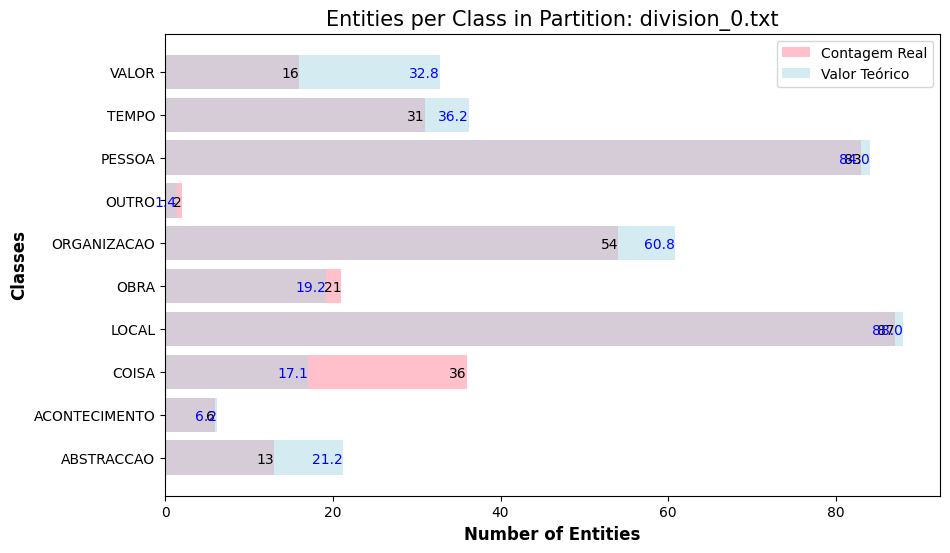

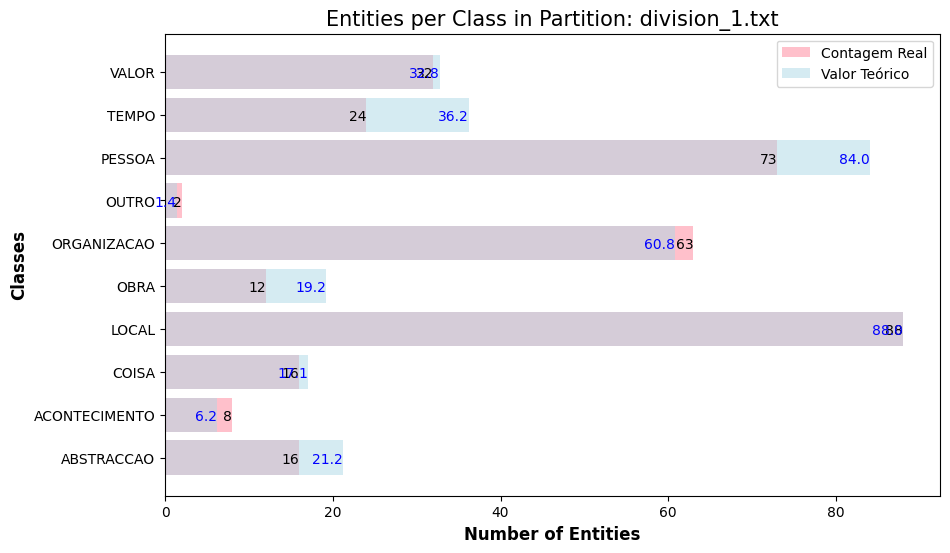

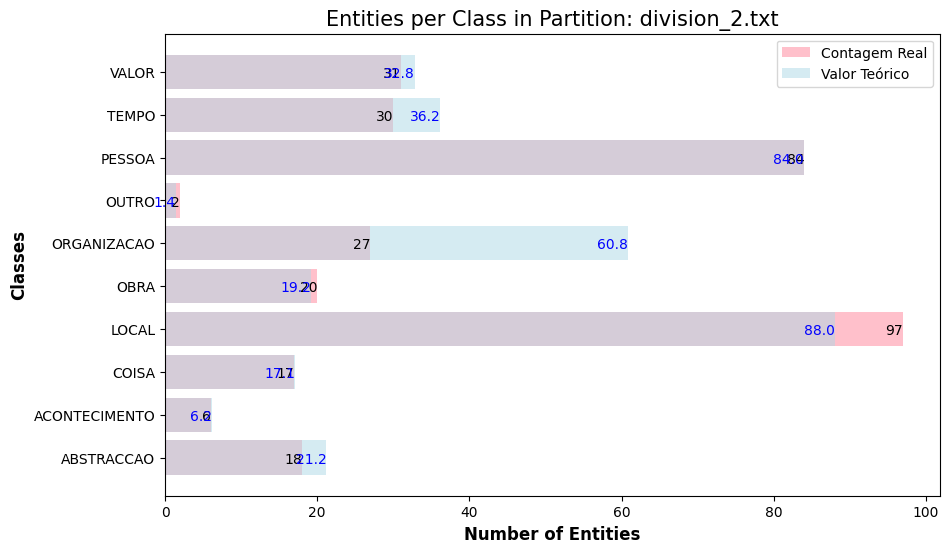

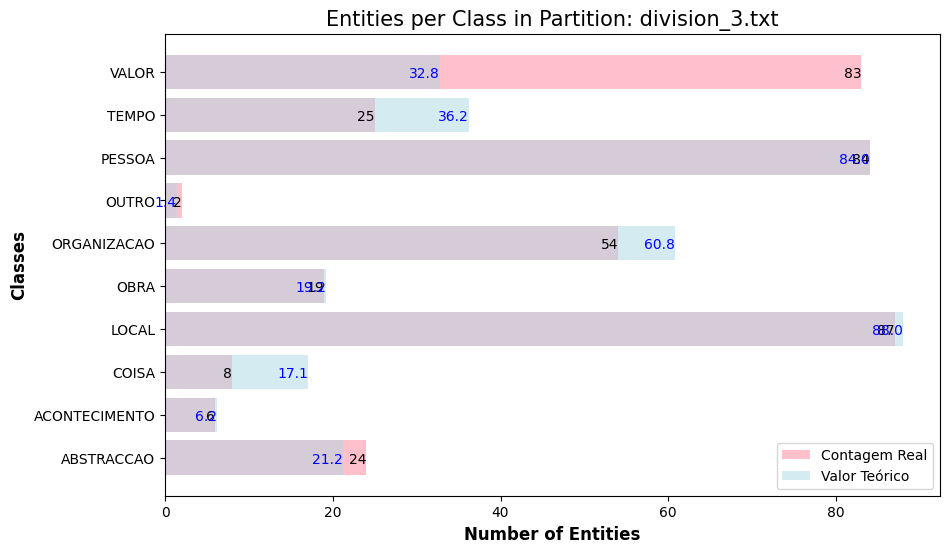

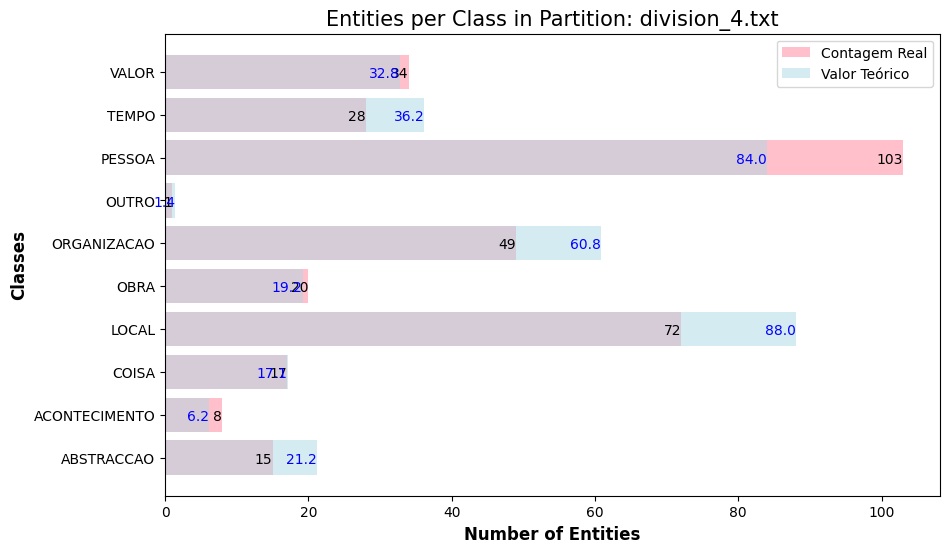

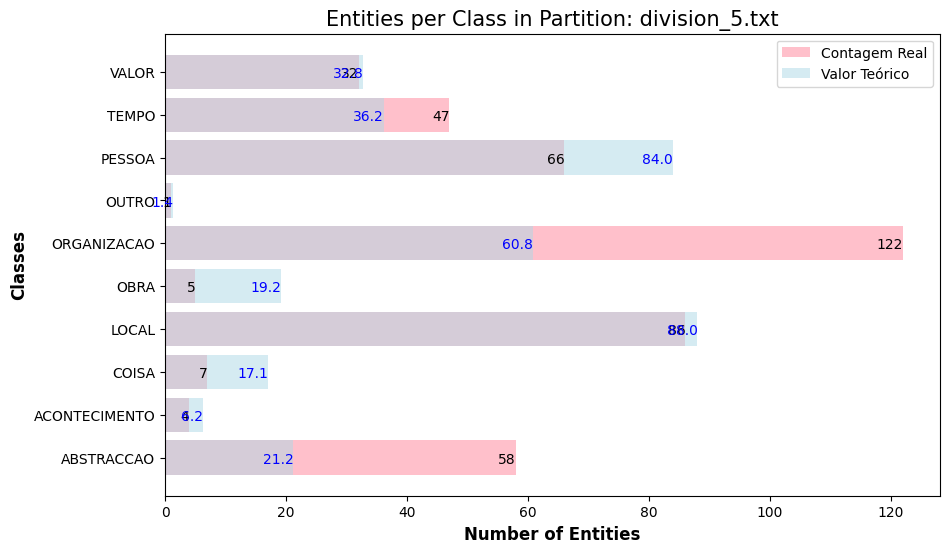

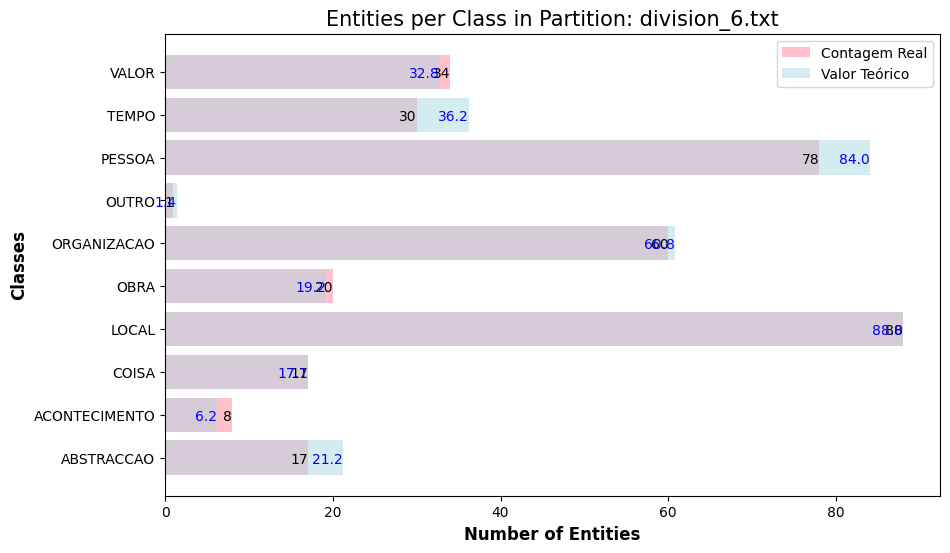

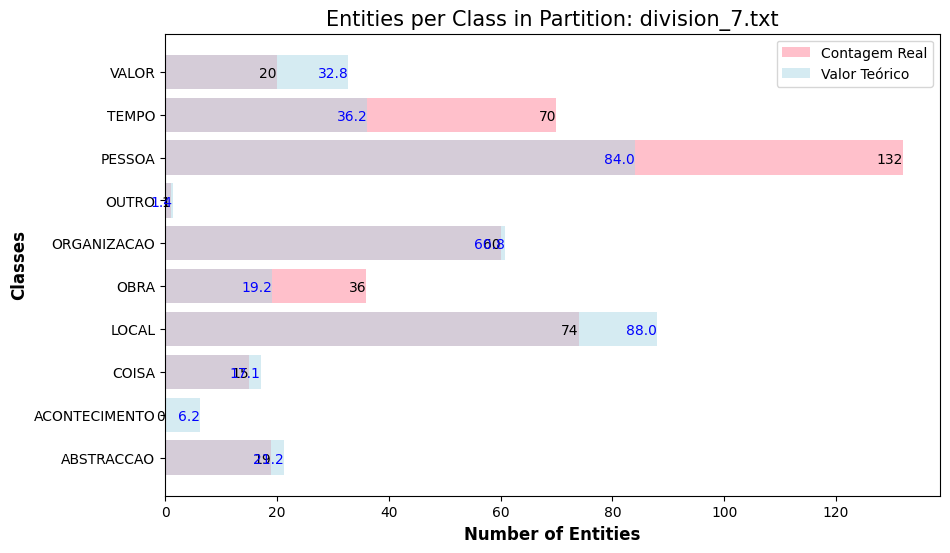

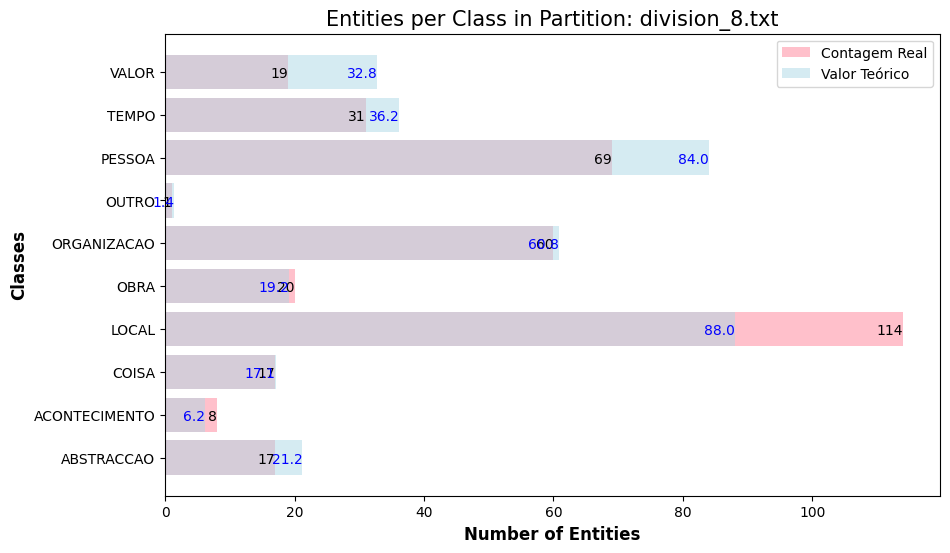

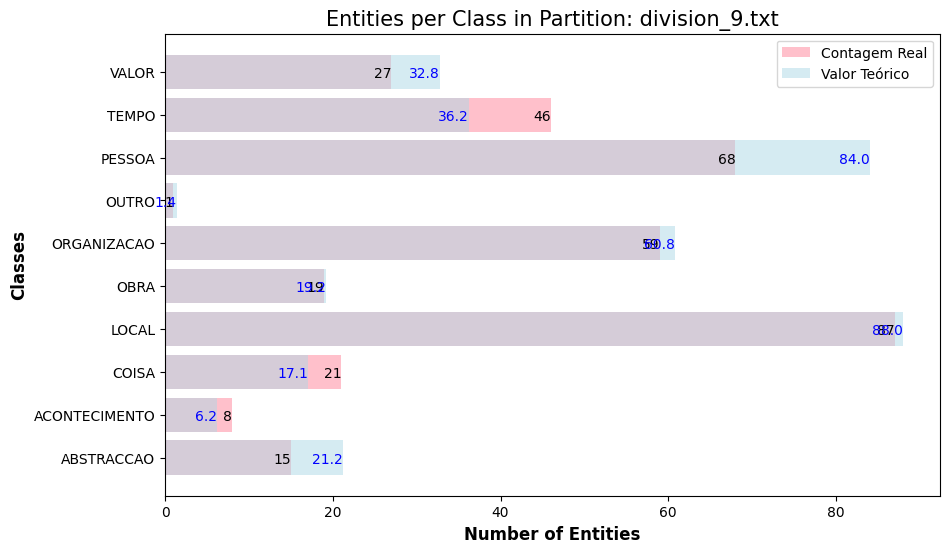

In [54]:
import os
import re
from collections import Counter
import matplotlib.pyplot as plt

# Diretório onde as partições estão salvas
base_dir = "../Base de Dados/HAREM/divisions/mini/iterative/"
number_divisions = 10

# Inicializar lista para as classes teóricas
unique_lbl_list = []

# Lista de abreviações
abbreviations = r"\b(?:Sr|S|Sra|Dr|Prof|Eng|Mme|Mestre|Vº|Vª)\.$"  # Abreviações que não devem terminar uma sentença
pattern = r"[.!?](\s|$)"  # Verifica ponto, exclamação ou interrogação seguidos de espaço ou fim da linha

# Contadores gerais
total_counts = Counter()
total_sentences_por_div = {}
total_tokens_por_div = {}

for file_name in sorted(os.listdir(base_dir)):
    if file_name.startswith("division_"):
        partition_path = os.path.join(base_dir, file_name)
        with open(partition_path, 'r', encoding='utf-8') as file:
            sentence_count = 0
            token_count = 0
            for line in file:
                line = line.strip()
                if line:
                    token_data = line.split()
                    label = token_data[-1]
                    token_count += 1  # Contando tokens
                    if label.startswith("B-"):  # Considerar apenas os rótulos com prefixo 'B-'
                        simplified_label = label.split("-")[-1]
                        unique_lbl_list.append(simplified_label)
                        total_counts[simplified_label] += 1
                    
                    # Verificar se a linha termina com ponto, exclamação ou interrogação
                    # e garantir que não seja uma abreviação
                    if re.search(pattern, line) and not re.search(abbreviations, line):
                        sentence_count += 1
            
            total_sentences_por_div[file_name] = sentence_count
            total_tokens_por_div[file_name] = token_count

# Obter classes teóricas únicas e ordenadas
classes_teoricas = sorted(set(unique_lbl_list))

# Calcular os valores teóricos dividindo as contagens totais por número de divisões
valores_teoricos = [total_counts[cls] / number_divisions for cls in classes_teoricas]

# Inicializando dicionários para armazenar contagens por partição
qtd_classes_por_div = {}
total_entidades_por_div = {}

# Iterar novamente pelas partições para calcular os valores reais
for file_name in sorted(os.listdir(base_dir)):
    if file_name.startswith("division_"):
        partition_path = os.path.join(base_dir, file_name)

        # Inicializar contador para esta partição
        labels_count = Counter()

        with open(partition_path, 'r', encoding='utf-8') as file:
            for line in file:
                line = line.strip()
                if line:
                    token_data = line.split()
                    label = token_data[-1]
                    if label.startswith("B-"):  # Considerar apenas os rótulos com prefixo 'B-'
                        simplified_label = label.split("-")[-1]
                        labels_count[simplified_label] += 1

        # Armazenar as contagens para a partição atual
        qtd_classes_por_div[file_name] = labels_count
        total_entidades_por_div[file_name] = sum(labels_count.values())

# Calculando o total geral de todas as partições
total_entidades_geral = sum(total_entidades_por_div.values())
total_sentences_geral = sum(total_sentences_por_div.values())
total_tokens_geral = sum(total_tokens_por_div.values())

# Exibindo os totais por partição e o total geral
print("Totais de entidades, sentenças e tokens por partição:")
for div_name in total_entidades_por_div:
    print(f"  {div_name}: {total_entidades_por_div[div_name]} entidades, "
          f"{total_sentences_por_div[div_name]} sentenças, "
          f"{total_tokens_por_div[div_name]} tokens")
print(f"\nTotal geral de entidades: {total_entidades_geral}")
print(f"Total geral de sentenças: {total_sentences_geral}")
print(f"Total geral de tokens: {total_tokens_geral}\n")

# Gerando os gráficos para cada partição
for div_name, labels_count in qtd_classes_por_div.items():
    # Ordenar as contagens conforme as classes teóricas
    qtd = [labels_count.get(cls, 0) for cls in classes_teoricas]

    plt.figure(figsize=(10, 6))
    bars_real = plt.barh(classes_teoricas, qtd, color="pink", label="Contagem Real")
    bars_teorico = plt.barh(classes_teoricas, valores_teoricos, color="lightblue", alpha=0.5, label="Valor Teórico")

    # Adicionando os valores nas barras
    for i, count in enumerate(qtd):
        plt.text(count, i, str(count), va="center_baseline", ha="right", fontsize=10)

    for i, teorico in enumerate(valores_teoricos):
        if teorico > 0:
            plt.text(teorico, i, f"{teorico:.1f}", va="center_baseline", ha="right", fontsize=10, color="blue")

    plt.title(f"Entities per Class in Partition: {div_name}", fontsize=15)
    plt.xlabel("Number of Entities", fontweight="bold", fontsize=12)
    plt.ylabel("Classes", fontweight="bold", fontsize=12)

    plt.legend()

    # Salvando o gráfico
    output_path = os.path.join(base_dir, f"entities_per_class_{div_name}.png")
    plt.savefig(output_path, dpi=300, format="png", bbox_inches="tight")
    print(f"Gráfico salvo: {output_path}")

print("Todos os gráficos foram gerados e salvos com sucesso!")


Totais de entidades, sentenças e tokens por partição:
  division_0.txt: 349 entidades, 287 sentenças, 5986 tokens
  division_1.txt: 334 entidades, 286 sentenças, 5685 tokens
  division_2.txt: 332 entidades, 246 sentenças, 4714 tokens
  division_3.txt: 392 entidades, 321 sentenças, 5986 tokens
  division_4.txt: 347 entidades, 257 sentenças, 5205 tokens
  division_5.txt: 428 entidades, 326 sentenças, 5611 tokens
  division_6.txt: 353 entidades, 265 sentenças, 5038 tokens
  division_7.txt: 427 entidades, 361 sentenças, 5552 tokens
  division_8.txt: 356 entidades, 282 sentenças, 5600 tokens
  division_9.txt: 351 entidades, 295 sentenças, 6523 tokens

Total geral de entidades: 3669
Total geral de sentenças: 2926
Total geral de tokens: 55900


Imagem única salva em: ../Base de Dados/HAREM/divisions/mini/iterative/entities_all_partitions_A4.png
Todos os gráficos foram gerados com sucesso!


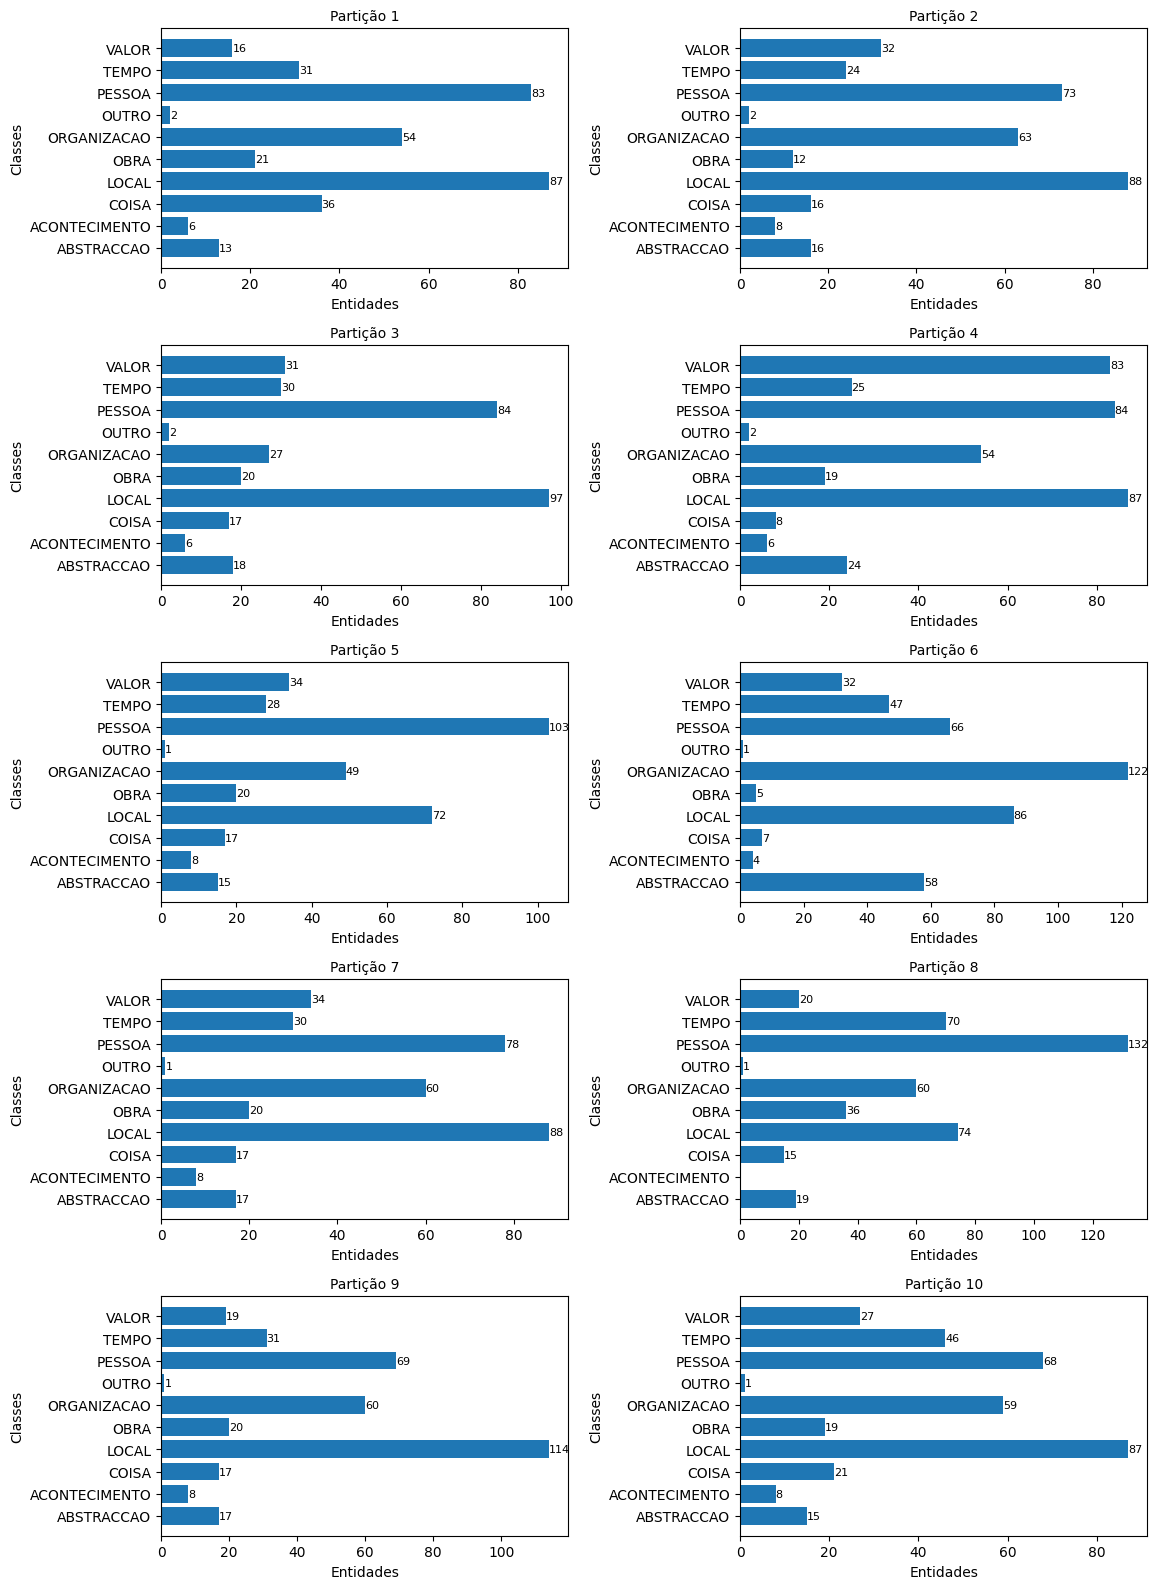

In [2]:
import os
from collections import Counter
import matplotlib.pyplot as plt
import re

# Diretório onde as partições estão salvas
base_dir = "../Base de Dados/HAREM/divisions/mini/iterative/"

# Inicializar lista para as classes
unique_lbl_list = []

# Lista de abreviações
abbreviations = r"\b(?:Sr|S|Sra|Dr|Prof|Eng|Mme|Mestre|Vº|Vª)\.$"
pattern = r"[.!?](\s|$)"

# Contadores gerais
total_counts = Counter()
total_sentences_por_div = {}
total_tokens_por_div = {}

# ===============================
# LISTAR E ORDENAR PARTIÇÕES
# ===============================
division_files = sorted(
    [f for f in os.listdir(base_dir) if f.startswith("division_")],
    key=lambda x: int(x.split("_")[1].split(".")[0])
)

# ===============================
# PRIMEIRA PASSAGEM: CONTAGENS GERAIS
# ===============================
for file_name in division_files:

    partition_path = os.path.join(base_dir, file_name)

    with open(partition_path, 'r', encoding='utf-8') as file:
        sentence_count = 0
        token_count = 0

        for line in file:
            line = line.strip()

            if line:
                token_data = line.split()
                label = token_data[-1]

                token_count += 1

                if label.startswith("B-"):
                    simplified_label = label.split("-")[-1]
                    unique_lbl_list.append(simplified_label)
                    total_counts[simplified_label] += 1

                if re.search(pattern, line) and not re.search(abbreviations, line):
                    sentence_count += 1

        total_sentences_por_div[file_name] = sentence_count
        total_tokens_por_div[file_name] = token_count

# Classes únicas ordenadas
classes_teoricas = sorted(set(unique_lbl_list))

# ===============================
# SEGUNDA PASSAGEM: CONTAGENS POR PARTIÇÃO
# ===============================
qtd_classes_por_div = {}
total_entidades_por_div = {}

for file_name in division_files:

    partition_path = os.path.join(base_dir, file_name)

    labels_count = Counter()

    with open(partition_path, 'r', encoding='utf-8') as file:

        for line in file:
            line = line.strip()

            if line:
                token_data = line.split()
                label = token_data[-1]

                if label.startswith("B-"):
                    simplified_label = label.split("-")[-1]
                    labels_count[simplified_label] += 1

    qtd_classes_por_div[file_name] = labels_count
    total_entidades_por_div[file_name] = sum(labels_count.values())

# ===============================
# TOTAIS GERAIS
# ===============================
total_entidades_geral = sum(total_entidades_por_div.values())
total_sentences_geral = sum(total_sentences_por_div.values())
total_tokens_geral = sum(total_tokens_por_div.values())

print("Totais de entidades, sentenças e tokens por partição:")

for div_name in division_files:
    print(
        f"  {div_name}: {total_entidades_por_div[div_name]} entidades, "
        f"{total_sentences_por_div[div_name]} sentenças, "
        f"{total_tokens_por_div[div_name]} tokens"
    )

print(f"\nTotal geral de entidades: {total_entidades_geral}")
print(f"Total geral de sentenças: {total_sentences_geral}")
print(f"Total geral de tokens: {total_tokens_geral}\n")

# ===============================
# GERAR UMA ÚNICA IMAGEM A4 COM TODAS AS PARTIÇÕES
# ===============================
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(11.69, 16))
axes = axes.flatten()

for ax, div_name in zip(axes, division_files):

    labels_count = qtd_classes_por_div[div_name]

    qtd = [labels_count.get(cls, 0) for cls in classes_teoricas]

    ax.barh(classes_teoricas, qtd)

    for i, count in enumerate(qtd):
        if count > 0:
            ax.text(count, i, str(count), va="center", fontsize=8)

    # division_0.txt -> Partição 1
    num_div = int(div_name.split("_")[1].split(".")[0]) + 1

    ax.set_title(f"Partição {num_div}", fontsize=10)
    ax.set_xlabel("Entidades")
    ax.set_ylabel("Classes")

plt.tight_layout()

output_path = os.path.join(base_dir, "entities_all_partitions_A4.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")

print(f"\nImagem única salva em: {output_path}")
print("Todos os gráficos foram gerados com sucesso!")